In [45]:
import tensorflow as tf

# Display the version
print(tf.__version__)

# other imports
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.layers import GlobalMaxPooling2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Model

2.20.0


In [46]:
# Load in the data
cifar10 = tf.keras.datasets.cifar10

# Distribute it to train and test set
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [47]:
# Reduce pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

# flatten the label values
y_train, y_test = y_train.flatten(), y_test.flatten()

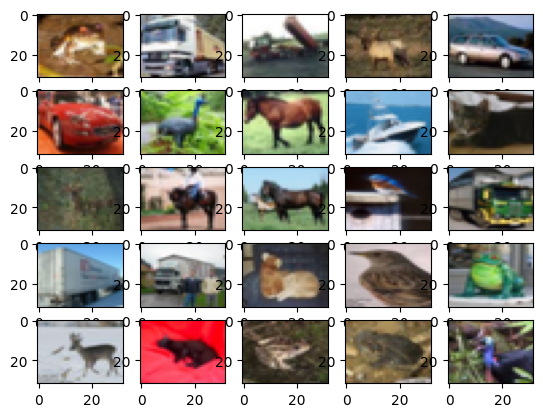

In [48]:
# visualize data by plotting images
fig, ax = plt.subplots(5, 5)
k = 0

for i in range(5):
	for j in range(5):
		ax[i][j].imshow(x_train[k], aspect='auto')
		k += 1

plt.show()

In [49]:
# number of classes
K = len(set(y_train))

# calculate total number of classes
# for output layer
print("number of classes:", K)

# Build the model using the functional API
# input layer
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Flatten()(x)
x = Dropout(0.2)(x)

# Hidden layer
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)

# last hidden layer i.e.. output layer
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# model description
model.summary()

number of classes: 10


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,397,226 (9.14 MB)

 Trainable params: 2,396,330 (9.14 MB)

 Non-trainable params: 896 (3.50 KB)

In [50]:
# Compile
model.compile(optimizer='adam',
			loss='sparse_categorical_crossentropy',
			metrics=['accuracy'])

In [51]:
# Fit
r = model.fit(
x_train, y_train, validation_data=(x_test, y_test), epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.5574 - loss: 1.2793 - val_accuracy: 0.6362 - val_loss: 1.0592
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7106 - loss: 0.8345 - val_accuracy: 0.6525 - val_loss: 1.1303
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7589 - loss: 0.6938 - val_accuracy: 0.7628 - val_loss: 0.7006
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7956 - loss: 0.5932 - val_accuracy: 0.7216 - val_loss: 0.9000
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8252 - loss: 0.5109 - val_accuracy: 0.7871 - val_loss: 0.6829


In [52]:
# Fit with data augmentation
# Note: if you run this AFTER calling
# the previous model.fit()
# it will CONTINUE training where it left off
batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(
width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)

train_generator = data_generator.flow(x_train, y_train, batch_size)
steps_per_epoch = x_train.shape[0] // batch_size

r = model.fit(train_generator, validation_data=(x_test, y_test),
			steps_per_epoch=steps_per_epoch, epochs=5)

Epoch 1/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.7672 - loss: 0.6932 - val_accuracy: 0.7497 - val_loss: 0.7716
Epoch 2/5
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7500 - loss: 0.7872

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step - accuracy: 0.7500 - loss: 0.7872 - val_accuracy: 0.7486 - val_loss: 0.7669
Epoch 3/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.7873 - loss: 0.6226 - val_accuracy: 0.7860 - val_loss: 0.6412
Epoch 4/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5625 - loss: 1.3978 - val_accuracy: 0.7895 - val_loss: 0.6275
Epoch 5/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7991 - loss: 0.5885 - val_accuracy: 0.8078 - val_loss: 0.5666


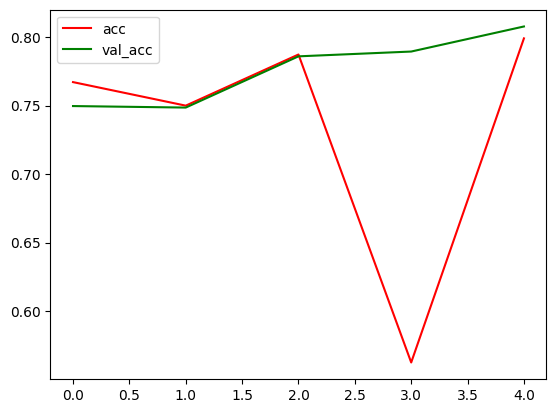

In [53]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='acc', color='red')
plt.plot(r.history['val_accuracy'], label='val_acc', color='green')
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
Original label is airplane and predicted label is airplane


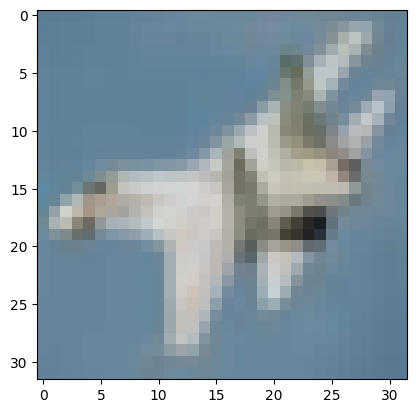

In [54]:
# label mapping

labels = '''airplane automobile bird cat deerdog frog horseship truck'''.split()

# select the image from our test dataset
image_number = 10

# display the image
plt.imshow(x_test[image_number])

# load the image in an array
n = np.array(x_test[image_number])

# reshape it
p = n.reshape(1, 32, 32, 3)

# pass in the network for prediction and
# save the predicted label
predicted_label = labels[model.predict(p).argmax()]

# load the original label
original_label = labels[y_test[image_number]]

# display the result
print("Original label is {} and predicted label is {}".format(
	original_label, predicted_label))

In [55]:
# save the model
model.save('CIFAR_10_tens.h5')

# Activity: call the trained model (.h5 file) to classify a new image from diffrent dataset to check the generalization of the trained model...

In [56]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests # Added for downloading images
import os       # Added for checking file existence

# 1. 加载已训练好的模型
model = tf.keras.models.load_model('CIFAR_10_tens.h5')

# 2. 类别标签（与训练时顺序一致）
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

# 3. 加载一张新图片（替换成你自己的图片路径）
img_path = 'my_test_image.jpg'

# Check if the image exists, if not, download a sample one
if not os.path.exists(img_path):
    print(f"Downloading a sample image as '{img_path}'...")
    # Using a common sample image URL for demonstration
    # You can replace this URL with any other image you want to test
    img_url = "https://www.cs.toronto.edu/~kriz/cifar-10-sample.png"
    response = requests.get(img_url)
    if response.status_code == 200:
        with open(img_path, 'wb') as f:
            f.write(response.content)
        print(f"Successfully downloaded '{img_path}'.")
    else:
        print(f"Failed to download image from {img_url}. Status code: {response.status_code}")
        print("Please provide a valid image file or URL.")

img = Image.open(img_path).convert('RGB')

# 4. 预处理：resize 到 32x32，归一化
img_resized = img.resize((32, 32))
img_array = np.array(img_resized) / 255.0
img_input = img_array.reshape(1, 32, 32, 3)

# 5. 预测
prediction = model.predict(img_input)
predicted_label = labels[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# 6. 显示结果
plt.imshow(img_resized)
plt.title(f"Predicted: {predicted_label} ({confidence:.1f}%)")
plt.axis('off')
plt.show()

print("All class probabilities:")
for label, prob in zip(labels, prediction[0]):
    print(f"  {label}: {prob*100:.2f}%")

UnidentifiedImageError: cannot identify image file 'my_test_image.jpg'

In [61]:
import requests # Using requests instead of urllib for more reliable downloads
import os

# 定义图片路径
img_path = 'my_test_image.jpg'

# 如果图片不存在，则下载一张示例图片
if not os.path.exists(img_path):
    print(f"Downloading a sample image as '{img_path}'...")
    # 使用一个可以公开访问的CIFAR-10样本图片URL
    img_url = "https://www.cs.toronto.edu/~kriz/cifar-10-sample.png"
    response = requests.get(img_url)
    if response.status_code == 200:
        with open(img_path, 'wb') as f:
            f.write(response.content)
        print(f"Successfully downloaded '{img_path}'.")
    else:
        print(f"Failed to download image from {img_url}. Status code: {response.status_code}")
        print("Please provide a valid image file or URL.")
else:
    print(f"'{img_path}' already exists. Skipping download.")

print("图片准备完成")

'my_test_image.jpg' already exists. Skipping download.
图片准备完成


In [62]:
import requests

url = 'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123045_tabby_cat.JPEG'
headers = {'User-Agent': 'Mozilla/5.0'}
r = requests.get(url, headers=headers)
with open('my_test_image.jpg', 'wb') as f:
    f.write(r.content)
print("图片下载完成")

图片下载完成


In [65]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('my_test_image.jpg')
print("图片尺寸:", img.size)
plt.imshow(img)
plt.axis('off')
plt.show()

UnidentifiedImageError: cannot identify image file 'my_test_image.jpg'

In [77]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print("上传成功:", img_path)

Saving 船.png to 船.png
上传成功: 船.png


图片尺寸: (824, 486)


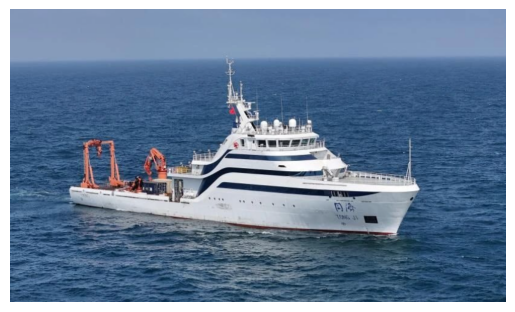

In [78]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(img_path)
print("图片尺寸:", img.size)
plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


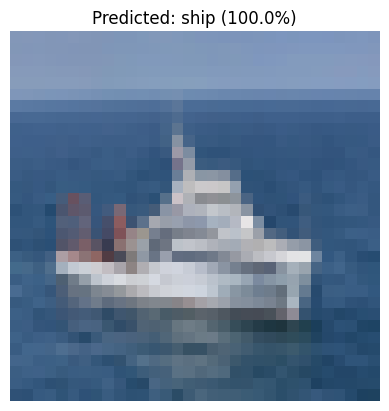

各类别概率：
  airplane: 0.00%
  automobile: 0.00%
  bird: 0.00%
  cat: 0.00%
  deer: 0.00%
  dog: 0.00%
  frog: 0.00%
  horse: 0.00%
  ship: 100.00%
  truck: 0.00%


In [79]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

# 预处理
img_resized = img.resize((32, 32))
img_array = np.array(img_resized) / 255.0
img_input = img_array.reshape(1, 32, 32, 3)

# 预测
prediction = model.predict(img_input)
predicted_label = labels[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# 显示结果
plt.imshow(img_resized)
plt.title(f"Predicted: {predicted_label} ({confidence:.1f}%)")
plt.axis('off')
plt.show()

print("各类别概率：")
for label, prob in zip(labels, prediction[0]):
    print(f"  {label}: {prob*100:.2f}%")

In [71]:
from google.colab import files
uploaded = files.upload()

Saving 青蛙.png to 青蛙.png


In [73]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# 加载模型
model = load_model('CIFAR_10_tens.h5')

# 加载你的图片（把 'your_image.jpg' 换成你上传的图片文件名）
img = image.load_img('4.png', target_size=(32, 32))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 预测
predictions = model.predict(img_array)
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
predicted_class = class_names[np.argmax(predictions)]

print(f"预测结果: {predicted_class}")

FileNotFoundError: [Errno 2] No such file or directory: '4.png'

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# 加载模型
model = load_model('CIFAR_10_tens.h5')

# 加载你的图片（把 'your_image.jpg' 换成你上传的图片文件名）
img = image.load_img('4.png', target_size=(32, 32))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 预测
predictions = model.predict(img_array)
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
predicted_class = class_names[np.argmax(predictions)]

print(f"预测结果: {predicted_class}")